In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

file_path = 'house-prices-advanced-regression-techniques/train.csv'
df = pd.read_csv(file_path)

df = df.drop(['GarageArea', 'Id'], axis=1, errors='ignore')

numeric_cols = df.select_dtypes(include=['number']).columns.drop('SalePrice') 
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
for col in non_numeric_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df)

X = df.drop('SalePrice', axis=1)  
y = df['SalePrice']               

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Feature shape::", X.shape)

数据预处理完成！特征维度: (1460, 286)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

# 计算均方误差
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# 计算 R^2 分数
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

Mean Squared Error: 848559025.5812366
R^2 Score: 0.8893711945671706


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}")

MSE: 848559025.5812366, RMSE: 29130.036484378743, MAE: 18202.662146334158


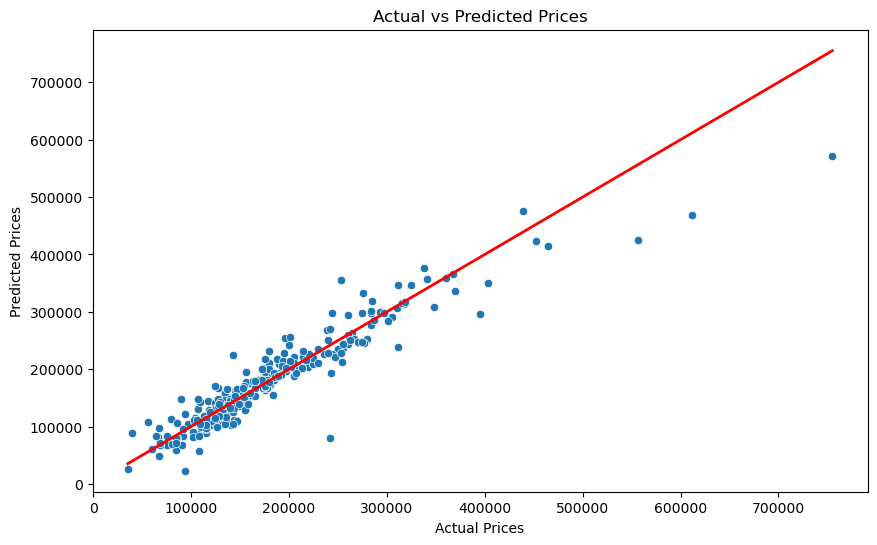

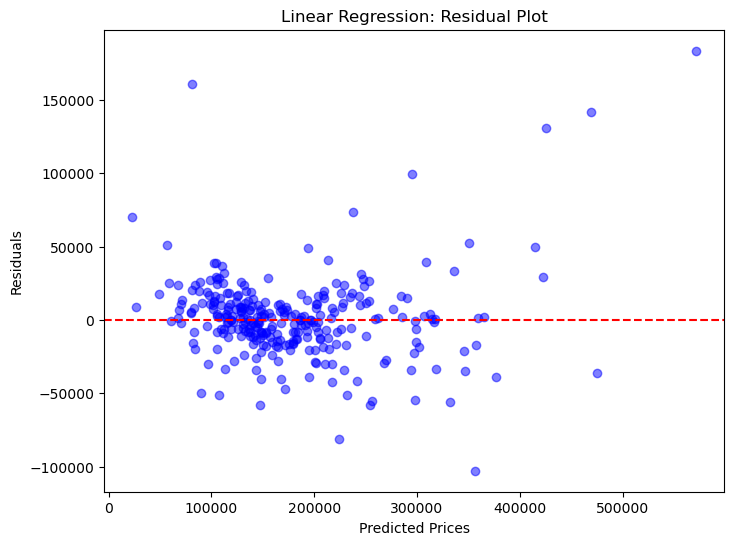

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 假设 y_test 和 y_pred 已经定义
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

# 残差图
residuals_lr = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals_lr, color='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot')
plt.show()

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# 加载和预处理数据（假设你已经有X和y）
# X_train, X_test, y_train, y_test 是预先划分好的训练集和测试集

# 初始化并训练决策树模型
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# 预测
y_pred_dt = dt_model.predict(X_test)

# 计算 MSE
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f'Mean Squared Error (Decision Tree): {mse_dt}')

# 计算 R² 分数
r2_dt = r2_score(y_test, y_pred_dt)
print(f'R² Score (Decision Tree): {r2_dt}')


Mean Squared Error (Decision Tree): 1705466885.3767123
R² Score (Decision Tree): 0.7776539303141132


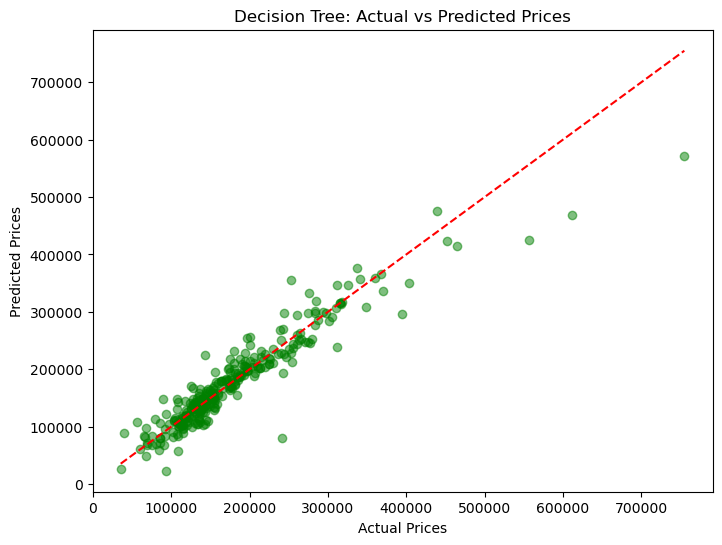

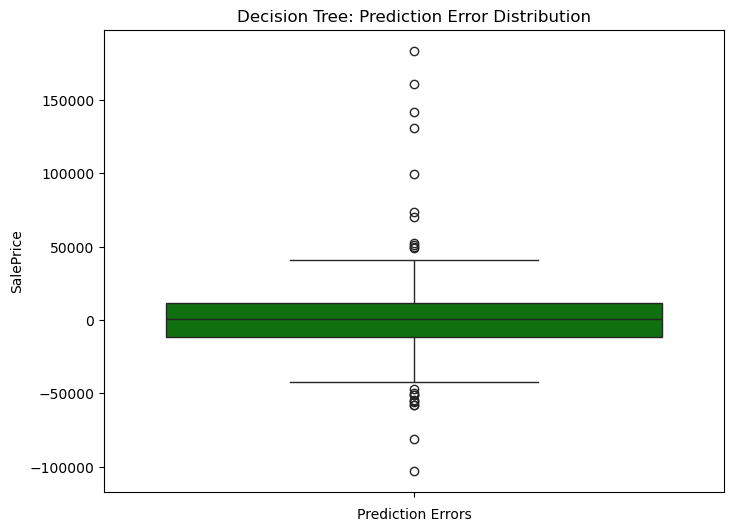

In [24]:
# 假设 y_pred 是决策树模型的预测房价

# 散点图：实际房价 vs 预测房价
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Decision Tree: Actual vs Predicted Prices')
plt.show()

# 箱线图：预测误差分布
errors_dt = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.boxplot(errors_dt, color='green')
plt.xlabel('Prediction Errors')
plt.title('Decision Tree: Prediction Error Distribution')
plt.show()


In [25]:
from sklearn.ensemble import RandomForestRegressor

# 初始化并训练随机森林模型
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# 预测
y_pred_rf = rf_model.predict(X_test)

# 计算 MSE
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'Mean Squared Error (Random Forest): {mse_rf}')

# 计算 R² 分数
r2_rf = r2_score(y_test, y_pred_rf)
print(f'R² Score (Random Forest): {r2_rf}')


Mean Squared Error (Random Forest): 827361085.5469745
R² Score (Random Forest): 0.8921348241002144


In [26]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
# 假设你已经有了 X 和 y
# X = ...
# y = ...

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 创建 XGBoost DMatrix
train_dmatrix = xgb.DMatrix(data=X_train, label=y_train)
test_dmatrix = xgb.DMatrix(data=X_test, label=y_test)

# 设置 XGBoost 参数
params = {
    'objective': 'reg:squarederror',  # 这是用于回归任务的目标函数
    'colsample_bytree': 0.3,          # 每棵树的样本列数的比例
    'learning_rate': 0.1,             # 学习率
    'max_depth': 5,                   # 树的最大深度
    'alpha': 10                       # L2 正则化项
}

# 训练模型
xg_reg = xgb.train(params=params, dtrain=train_dmatrix, num_boost_round=100)
# 预测
y_pred_xgb = xg_reg.predict(test_dmatrix)

# 计算 MSE
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f'Mean Squared Error (XGBoost): {mse_xgb}')

# 计算 R² Score
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'R² Score (XGBoost): {r2_xgb}')


Mean Squared Error (XGBoost): 587575936.0
R² Score (XGBoost): 0.9233962297439575


In [27]:
from sklearn.model_selection import GridSearchCV

xg_reg = xgb.XGBRegressor(objective='reg:squarederror')

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.3, 0.7]
}

grid_search = GridSearchCV(estimator=xg_reg, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print(f'Best Mean Squared Error (XGBoost): {mse_best_xgb}')
print(f'Best R² Score (XGBoost): {r2_best_xgb}')


Best Mean Squared Error (XGBoost): 645033280.0
Best R² Score (XGBoost): 0.9159053564071655


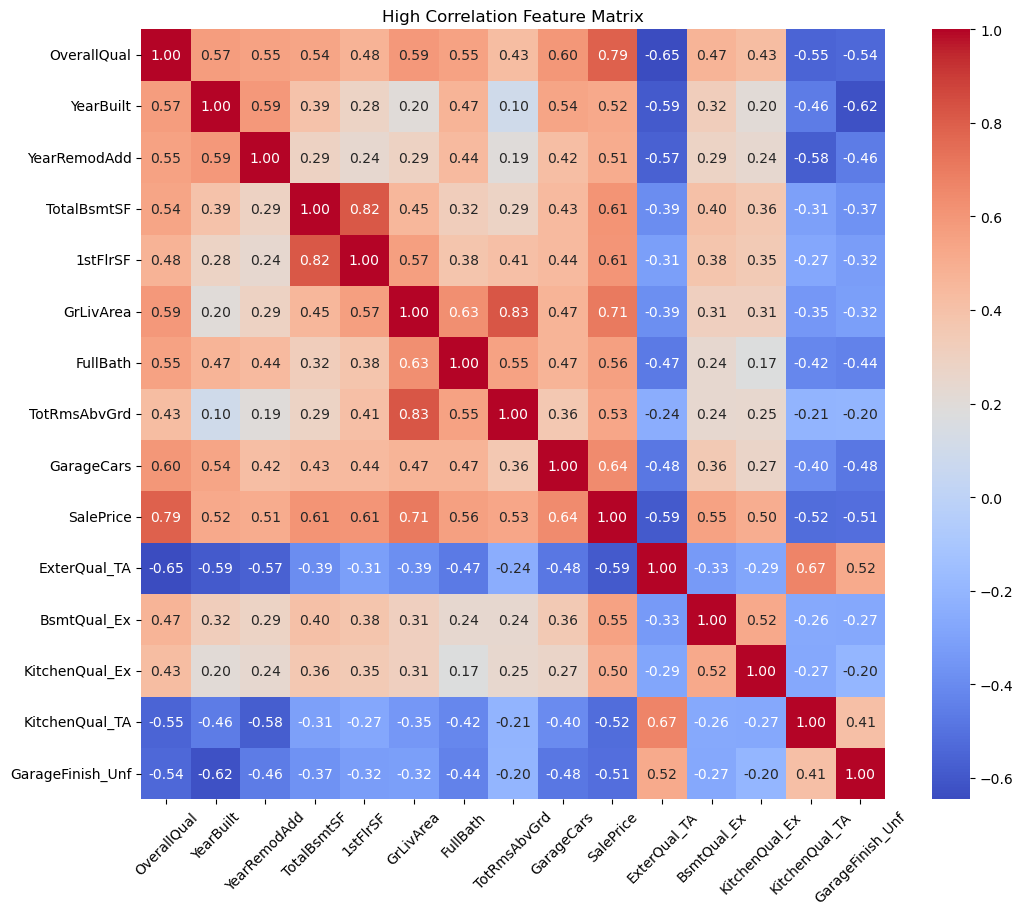

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 筛选与目标变量高度相关的特征 (假设目标变量为 'SalePrice')
corr_matrix = df.corr()
high_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]

# 生成热力图
plt.figure(figsize=(12, 10))
sns.heatmap(df[high_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('High Correlation Feature Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

